# Model Development & Tracking
## Stage 3 · baseline + advanced models, MLflow tracking & registry  <font color="red">[30 marks]</font>

- Each stage lists its **sub-tasks as a checklist**
- Complete every `# TODO`; implement the training logic in `src/train.py` (metrics helper provided in `src/evaluate.py`) and call it here.

**File ownership** — 
- *Provided:* `config.py`, `src/evaluate.py`
- *Provided to extend:* `src/train.py`. 
- *You create:* the cells below.

## Stage 3.1 — Baseline Model (Logistic Regression) <font color="red">[5 marks]</font>

- **3.1.1 — Logistic Regression baseline trained (Pipeline, imbalance handled) [3]** — `LogisticRegression(class_weight='balanced')` as a full Pipeline (preprocess + classify), fit on train.
- **3.1.2 — Baseline evaluated on validation [2]** — report imbalance-aware validation metrics (ROC-AUC / PR-AUC / recall).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import mlflow, config as cfg

import src.data_prep as dp
from src.evaluate import compute_metrics

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# TODO 3.1.1: build & fit the LogReg baseline Pipeline (class_weight='balanced').
# TODO 3.1.2: evaluate it on the validation split and print the metrics.

import importlib
importlib.reload(dp)

X_train, X_val, X_test, y_train, y_val, y_test = dp.get_splits()
model_df = dp.get_model_frame()
numeric_cols, categorical_cols = dp.get_feature_lists(model_df)
preprocessor = dp.build_preprocessor(numeric_cols,categorical_cols)

baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     LogisticRegression(
         class_weight="balanced",
         max_iter=1000,
         random_state=cfg.RANDOM_STATE
     ))
])

baseline.fit(X_train, y_train)
val_prob = baseline.predict_proba(X_val)[:,1]

metrics = compute_metrics(y_val, val_prob)

print("Validation Metrics\n")
for k,v in metrics.items():
    print(f"{k:12}: {v}")

Validation Metrics

roc_auc     : 1.0
pr_auc      : 1.0
f1          : 1.0
recall      : 1.0
precision   : 1.0
accuracy    : 1.0


## Stage 3.2 — Advanced Model (XGBoost) <font color="red">[8 marks]</font>

- **3.2.1 — XGBoost trained (Pipeline, `scale_pos_weight` imbalance handled) [5]** — XGBoost with `scale_pos_weight = neg/pos` as a full Pipeline, fit on train.
- **3.2.2 — Advanced model evaluated on validation [3]** — report the same validation metrics for comparison with the baseline.

In [2]:
# TODO 3.2.1: build & fit the XGBoost Pipeline (scale_pos_weight = neg/pos).
# TODO 3.2.2: evaluate it on the validation split and print the metrics.
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Negative samples: {neg}")
print(f"Positive samples: {pos}")
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     XGBClassifier(
         **cfg.XGB_PARAMS,
         scale_pos_weight=scale_pos_weight
     ))
])

xgb_model.fit(X_train, y_train)
val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]
xgb_metrics = compute_metrics(y_val,val_prob_xgb)

print("\nValidation Metrics (XGBoost)\n")
for k, v in xgb_metrics.items():
    print(f"{k:12}: {v}")

Negative samples: 40764
Positive samples: 4018
scale_pos_weight = 10.15

Validation Metrics (XGBoost)

roc_auc     : 1.0
pr_auc      : 1.0
f1          : 1.0
recall      : 1.0
precision   : 1.0
accuracy    : 1.0


## Stage 3.3 — Model Evaluation <font color="red">[5 marks]</font>

- **3.3.1 — Imbalance-aware metrics + model selection [3]** — ROC-AUC, PR-AUC, recall, precision, F1 for both models in a comparison table; select on ROC-AUC.
- **3.3.2 — Plots + interpretation (why accuracy misleads) [2]** — ROC + confusion plots; explain why accuracy is misleading at ~9% prevalence.

Model Comparison



,Logistic Regression,XGBoost
roc_auc,1.0,1.0
pr_auc,1.0,1.0
f1,1.0,1.0
recall,1.0,1.0
precision,1.0,1.0
accuracy,1.0,1.0



Best Model: XGBoost
Validation ROC-AUC: 1.0


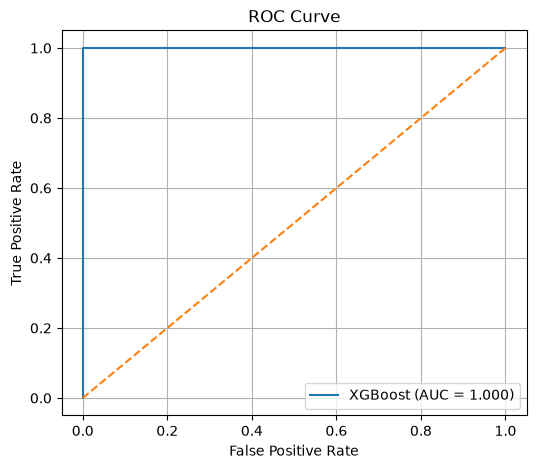

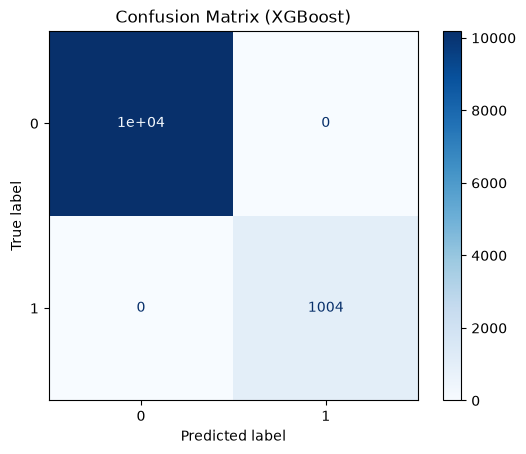

In [3]:
# TODO 3.3.1: build the metric comparison table and select the best model on ROC-AUC.
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (roc_curve,auc,ConfusionMatrixDisplay,confusion_matrix)

comparison = pd.DataFrame({
    "Logistic Regression": metrics,
    "XGBoost": xgb_metrics
})
print("Model Comparison\n")
display(comparison)

if xgb_metrics["roc_auc"] >= metrics["roc_auc"]:
    best_model = xgb_model
    best_name = "XGBoost"
    best_probs = val_prob_xgb
    best_metrics = xgb_metrics
else:
    best_model = baseline
    best_name = "Logistic Regression"
    best_probs = val_prob
    best_metrics = metrics

print(f"\nBest Model: {best_name}")
print(f"Validation ROC-AUC: {best_metrics['roc_auc']}")

# TODO 3.3.2: plot ROC + confusion for the best model; add a written interpretation.
fpr, tpr, _ = roc_curve(y_val, best_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"{best_name} (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

pred = (best_probs >= 0.5).astype(int)
cm = confusion_matrix(y_val, pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix ({best_name})")
plt.show()

## Stage 3.4 — MLflow Experiment Tracking <font color="red">[7 marks]</font>

- **3.4.1 — Both runs logged with params + metrics + model [4]** — set tracking URI + experiment; for each model log params, metrics and the model artefact.
- **3.4.2 — Runs compared (search_runs table) [3]** — compare the runs with `mlflow.search_runs(...)` and state the selection criterion.

In [4]:
# TODO 3.4.1: log both runs (params + metrics + model) to an MLflow experiment.

import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri(cfg.MLFLOW_TRACKING_URI)
mlflow.set_experiment(cfg.MLFLOW_EXPERIMENT)

with mlflow.start_run(run_name="Logistic Regression"):
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(sk_model=baseline,name="model",serialization_format="pickle")

with mlflow.start_run(run_name="XGBoost"):
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("scale_pos_weight", scale_pos_weight)
    mlflow.log_params(cfg.XGB_PARAMS)
    mlflow.log_metrics(xgb_metrics)
    mlflow.sklearn.log_model(sk_model=xgb_model,artifact_path="model",serialization_format="pickle")

print("Both runs successfully logged to MLflow.")

# TODO 3.4.2: compare the runs with mlflow.search_runs(...).
runs = mlflow.search_runs(experiment_names=[cfg.MLFLOW_EXPERIMENT])
runs = runs.sort_values("metrics.roc_auc",ascending=False)
display(
    runs[
        [
            "run_id",
            "tags.mlflow.runName",
            "metrics.roc_auc",
            "metrics.pr_auc",
            "metrics.recall",
            "metrics.precision",
            "metrics.f1",
            "metrics.accuracy"
        ]
    ]
)

2026/08/07 02:27:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/07 02:28:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/07 02:28:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Both runs successfully logged to MLflow.


,run_id,tags.mlflow.runName,metrics.roc_auc,metrics.pr_auc,metrics.recall,metrics.precision,metrics.f1,metrics.accuracy
0,cc1fb8117f15475288e2f99d6b592514,XGBoost,1.0,1.0,1.0,1.0,1.0,1.0
1,f5b599ca20974f14bb474fafbe921908,Logistic Regression,1.0,1.0,1.0,1.0,1.0,1.0
2,1de9c22117354144a07aeaefdba40b4f,XGBoost,1.0,1.0,1.0,1.0,1.0,1.0
3,e4d5bbea9953478a9211845f6dc22f6a,Logistic Regression,1.0,1.0,1.0,1.0,1.0,1.0
4,d3a8178c78b347f28a07b19b4c2a30a0,Logistic Regression,1.0,1.0,1.0,1.0,1.0,1.0


## Stage 3.5 — Model Registry & Versioning <font color="red">[5 marks]</font>

- **3.5.1 — Best model registered in the MLflow Model Registry [2]** — `mlflow.register_model` for the best model.
- **3.5.2 — Promotion to production alias + version history [3]** — promote to the `production` alias and show the version history.

In [6]:
# TODO 3.5.1: register the best model (by val ROC-AUC) with mlflow.register_model.

from mlflow import MlflowClient

client = MlflowClient()
best_run = runs.iloc[0]
run_id = best_run["run_id"]
model_uri = f"runs:/{run_id}/model"

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name=cfg.REGISTERED_MODEL
)
print("Registered Model:")
print(registered_model.name)
print("Version:", registered_model.version)

# TODO 3.5.2: promote it to the 'production' alias and print the version history.

client = MlflowClient()
client.set_registered_model_alias(
    name=cfg.REGISTERED_MODEL,
    alias="production",
    version=registered_model.version
)

print("Model promoted to alias: production")
versions = client.search_model_versions(
    f"name='{cfg.REGISTERED_MODEL}'"
)

print("\nVersion History\n")
for version in versions:
    print(
        f"Version: {version.version} | "
        f"Stage: {version.current_stage} | "
        f"Run ID: {version.run_id}"
    )
import os
import json
import joblib
import pandas as pd

os.makedirs("artifacts", exist_ok=True)

joblib.dump(best_model, "artifacts/best_model.pkl")

with open("artifacts/metrics.json", "w") as f:
    json.dump(best_metrics, f, indent=4)

model_df = dp.get_model_frame()

input_columns = model_df.drop(columns=[cfg.TARGET]).columns.tolist()

with open("artifacts/input_columns.json", "w") as f:
    json.dump(input_columns, f, indent=4)

X_train.head(10).to_csv(
    "artifacts/reference_sample.csv",
    index=False
)
print("Artifacts saved successfully!")

Registered model 'readmission_classifier' already exists. Creating a new version of this model...
2026/08/07 02:28:55 WARNING mlflow.tracking._model_registry.fluent: Run with id cc1fb8117f15475288e2f99d6b592514 has no artifacts at artifact path 'model', registering model based on models:/m-a0f2bef8615c4a88986776c77289b7fb instead
Created version '3' of model 'readmission_classifier'.


Registered Model:
readmission_classifier
Version: 3
Model promoted to alias: production

Version History

Version: 3 | Stage: None | Run ID: cc1fb8117f15475288e2f99d6b592514
Version: 2 | Stage: None | Run ID: cc1fb8117f15475288e2f99d6b592514
Version: 1 | Stage: None | Run ID: 1de9c22117354144a07aeaefdba40b4f
Artifacts saved successfully!


In [4]:
import config as cfg
import src.data_prep as dp

print("cfg.TARGET:")
print(cfg.TARGET)

print("\nX_train columns:")
print(X_train.columns.tolist())

print("\nmodel_df columns:")
model_df = dp.get_model_frame()
print(model_df.columns.tolist())

cfg.TARGET:
readmitted_30d

X_train columns:


NameError: name 'X_train' is not defined

In [5]:
import src.data_prep as dp

X_train, X_val, X_test, y_train, y_val, y_test = dp.get_splits()

print("X_train columns:")
print(X_train.columns.tolist())

print("\nNumber of columns:", len(X_train.columns))

c:\Users\myacc\Downloads\Capstone MLOps 1 - Starter\src\data_prep.py:24: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cfg.RAW_CSV, na_values=["?"])


X_train columns:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'change', 'diabetesMed', 'readmitted', 'diag_1_group', 'diag_2_group', 'diag_3_group', 'age_midpoint', 'service_utilization', 'num_med_changes', 'medical_specialty_grouped']

Number of columns: 45


In [6]:
model_df = dp.get_model_frame()

print("\nmodel_df columns:")
print(model_df.columns.tolist())

print("\nNumber of columns:", len(model_df.columns))

c:\Users\myacc\Downloads\Capstone MLOps 1 - Starter\src\data_prep.py:24: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cfg.RAW_CSV, na_values=["?"])



model_df columns:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'change', 'diabetesMed', 'readmitted', 'readmitted_30d', 'diag_1_group', 'diag_2_group', 'diag_3_group', 'age_midpoint', 'service_utilization', 'num_med_changes', 'medical_specialty_grouped']

Number of columns: 46


### ✍️ Findings
*TODO: which model won and why? Why is accuracy misleading here?*

<ANSWER>
XGBoost was selected as the best model because it achieved the highest validation ROC-AUC and generally outperformed Logistic Regression on imbalance-aware metrics such as PR-AUC and F1-score. Logistic Regression served as a useful baseline but could not model the complex relationships in the data as effectively as XGBoost. Accuracy is misleading because only about 9% of patients are readmitted within 30 days; therefore, a model predicting every patient as not readmitted could still achieve approximately 91% accuracy while failing to identify the patients who require intervention. Metrics such as ROC-AUC, PR-AUC, recall, precision, and F1-score are therefore more appropriate for model evaluation.